```python
"""
fork from python-rl and pybrain for visualization
"""
import numpy as np
from matplotlib.pyplot import ion, draw, Rectangle, Line2D
import matplotlib.pyplot as plt

# If theta  has gone past our conceptual limits of [-pi,pi]
# map it onto the equivalent angle that is in the accepted range (by adding or subtracting 2pi)
     
def remap_angle(theta):
    return _remap_angle(theta)
    
def _remap_angle(theta):
    while theta < -np.pi:
        theta += 2. * np.pi
    while theta > np.pi:
        theta -= 2. * np.pi
    return theta
    

## loss function given a state vector. the elements of the state vector are
## [cart location, cart velocity, pole angle, pole angular velocity]
def _loss(state):
    sig = 0.5
    return 1-np.exp(-np.dot(state,state)/(2.0 * sig**2))

def loss(state):
    return _loss(state)

class CartPole:
    """Cart Pole environment. This implementation allows multiple poles,
    noisy action, and random starts. It has been checked repeatedly for
    'correctness', specifically the direction of gravity. Some implementations of
    cart pole on the internet have the gravity constant inverted. The way to check is to
    limit the force to be zero, start from a valid random start state and watch how long
    it takes for the pole to fall. If the pole falls almost immediately, you're all set. If it takes
    tens or hundreds of steps then you have gravity inverted. It will tend to still fall because
    of round off errors that cause the oscillations to grow until it eventually falls.
    """

    def __init__(self, visual=False):
        self.cart_location = 0.0
        self.cart_velocity = 0.0
        self.pole_angle = np.pi    # angle is defined to be zero when the pole is upright, pi when hanging vertically down
        self.pole_velocity = 0.0
        self.visual = visual

        # Setup pole lengths and masses based on scale of each pole
        # (Papers using multi-poles tend to have them either same lengths/masses
        #   or they vary by some scalar from the other poles)
        self.pole_length = 0.5 
        self.pole_mass = 0.5 

        self.mu_c = 0.001 #   # friction coefficient of the cart
        self.mu_p = 0.001 # # friction coefficient of the pole
        self.sim_steps = 50         # number of Euler integration steps to perform in one go
        self.delta_time = 0.1       # time step of the Euler integrator
        self.max_force = 20.
        self.gravity = 9.8
        self.cart_mass = 0.5

        # for plotting
        self.cartwidth = 1.0
        self.cartheight = 0.2

        if self.visual:
            self.drawPlot()

    def setState(self, state):
        self.cart_location = state[0]
        self.cart_velocity = state[1]
        self.pole_angle = state[2]
        self.pole_velocity = state[3]
            
    def getState(self):
        return np.array([self.cart_location,self.cart_velocity,self.pole_angle,self.pole_velocity])

    # reset the state vector to the initial state (down-hanging pole)
    def reset(self):
        self.cart_location = 0.0
        self.cart_velocity = 0.0
        self.pole_angle = np.pi
        self.pole_velocity = 0.0

    # This is where the equations of motion are implemented
    def performAction(self, action = 0.0):
        # prevent the force from being too large
        force = self.max_force * np.tanh(action/self.max_force)

        # integrate forward the equations of motion using the Euler method
        for step in range(self.sim_steps):
            s = np.sin(self.pole_angle)
            c = np.cos(self.pole_angle)
            m = 4.0*(self.cart_mass+self.pole_mass)-3.0*self.pole_mass*(c**2)
            
            cart_accel = (2.0*(self.pole_length*self.pole_mass*(self.pole_velocity**2)*s+2.0*(force-self.mu_c*self.cart_velocity))\
                -3.0*self.pole_mass*self.gravity*c*s + 6.0*self.mu_p*self.pole_velocity*c/self.pole_length)/m
            
            pole_accel = (-3.0*c*(2.0/self.pole_length)*(self.pole_length/2.0*self.pole_mass*(self.pole_velocity**2)*s + force-self.mu_c*self.cart_velocity)+\
                6.0*(self.cart_mass+self.pole_mass)/(self.pole_mass*self.pole_length)*\
                (self.pole_mass*self.gravity*s - 2.0/self.pole_length*self.mu_p*self.pole_velocity) \
                )/m

            # Update state variables
            dt = (self.delta_time / float(self.sim_steps))
            # Do the updates in this order, so that we get semi-implicit Euler that is simplectic rather than forward-Euler which is not. 
            self.cart_velocity += dt * cart_accel
            self.pole_velocity += dt * pole_accel
            self.pole_angle    += dt * self.pole_velocity
            self.cart_location += dt * self.cart_velocity

        if self.visual:
            self._render()

    # remapping as a member function
    def remap_angle(self):
        self.pole_angle = _remap_angle(self.pole_angle)
    
    # the loss function that the policy will try to optimise (lower) as a member function
    def loss(self):
        return _loss(self.getState())
    

   # the following are graphics routines
    def drawPlot(self):
        ion()
        self.fig = plt.figure()
        # draw cart
        self.axes = self.fig.add_subplot(111, aspect='equal')
        self.box = Rectangle(xy=(self.cart_location - self.cartwidth / 2.0, -self.cartheight), 
                             width=self.cartwidth, height=self.cartheight)
        self.axes.add_artist(self.box)
        self.box.set_clip_box(self.axes.bbox)

        # draw pole
        self.pole = Line2D([self.cart_location, self.cart_location + np.sin(self.pole_angle)], 
                           [0, np.cos(self.pole_angle)], linewidth=3, color='black')
        self.axes.add_artist(self.pole)
        self.pole.set_clip_box(self.axes.bbox)

        # set axes limits
        self.axes.set_xlim(-10, 10)
        self.axes.set_ylim(-0.5, 2)
        


    def _render(self):
        self.box.set_x(self.cart_location - self.cartwidth / 2.0)
        self.pole.set_xdata([self.cart_location, self.cart_location + np.sin(self.pole_angle)])
        self.pole.set_ydata([0, np.cos(self.pole_angle)])
        self.fig.show()
        
        plt.pause(0.2)
```

In [2]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd().resolve()

PROJECT_ROOT = current_dir

DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
REPORT_DIR = PROJECT_ROOT / "reports"
SRC_DIR = PROJECT_ROOT / "src"

for folder in [DATA_DIR, FIGURE_DIR, NOTEBOOK_DIR, REPORT_DIR, SRC_DIR]:
    folder.mkdir(exist_ok=True)

np.random.seed(0)

print("Project root:", PROJECT_ROOT)
print("Figure dir:", FIGURE_DIR)

Project root: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning
Figure dir: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures


In [3]:
from cartpole import CartPole, remap_angle

system = CartPole(visual=False)

print("Initial state:")
print(system.getState())

print("\nSystem parameters:")
print("delta_time:", system.delta_time)
print("sim_steps:", system.sim_steps)
print("max_force:", system.max_force)
print("gravity:", system.gravity)
print("cart_mass:", system.cart_mass)
print("pole_mass:", system.pole_mass)
print("pole_length:", system.pole_length)

Initial state:
[0.         0.         3.14159265 0.        ]

System parameters:
delta_time: 0.1
sim_steps: 50
max_force: 20.0
gravity: 9.8
cart_mass: 0.5
pole_mass: 0.5
pole_length: 0.5


In [4]:
def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved figure to:", path)
    return path

In [5]:
def rollout_free_dynamics(initial_state, num_steps):
    """
    Roll out the CartPole system with zero applied force.

    initial_state shape: (4,)
    returned trajectory shape: (num_steps + 1, 4)

    State order:
        [cart position, cart velocity, pole angle, pole angular velocity]
    """
    system = CartPole(visual=False)
    system.setState(initial_state)

    trajectory = np.zeros((num_steps + 1, 4))
    trajectory[0] = system.getState()

    for step in range(num_steps):
        system.performAction(0.0)
        trajectory[step + 1] = system.getState()

    return trajectory

In [6]:
def remap_angle_array(theta_values):
    """
    Apply cartpole.remap_angle to an array of angle values.
    """
    return np.array([remap_angle(theta) for theta in theta_values])


def trajectory_with_remapped_angle(trajectory):
    """
    Copy trajectory and remap only the angle column for plotting.
    """
    trajectory_plot = trajectory.copy()
    trajectory_plot[:, 2] = remap_angle_array(trajectory[:, 2])
    return trajectory_plot

In [7]:
num_steps = 300

initial_conditions = {
    "small_oscillation": np.array([0.0, 0.0, np.pi, 2.0]),
    "large_oscillation": np.array([0.0, 0.0, np.pi, 8.0]),
    "full_rotation": np.array([0.0, 0.0, np.pi, 15.0]),
}

rollouts = {}

for name, initial_state in initial_conditions.items():
    trajectory = rollout_free_dynamics(initial_state, num_steps)
    rollouts[name] = trajectory

    print(name)
    print("  initial_state:", initial_state)
    print("  trajectory shape:", trajectory.shape)
    print("  final state:", trajectory[-1])
    print("  raw theta min:", trajectory[:, 2].min())
    print("  raw theta max:", trajectory[:, 2].max())
    print()

small_oscillation
  initial_state: [0.         0.         3.14159265 2.        ]
  trajectory shape: (301, 4)
  final state: [-7.37736573 -0.35679793  3.23206635 -0.91719482]
  raw theta min: 2.8530078667286176
  raw theta max: 3.4260643740381025

large_oscillation
  initial_state: [0.         0.         3.14159265 8.        ]
  trajectory shape: (301, 4)
  final state: [-29.48327385  -1.0920594    3.76649672  -1.19098936]
  raw theta min: 1.9363435740659203
  raw theta max: 4.377220499018058

full_rotation
  initial_state: [ 0.          0.          3.14159265 15.        ]
  trajectory shape: (301, 4)
  final state: [-61.58981673  -0.99382585  46.8092007    8.84062777]
  raw theta min: 3.141592653589793
  raw theta max: 49.98908101894895



In [8]:
state_labels = [
    "cart position x",
    "cart velocity x_dot",
    "pole angle theta",
    "pole angular velocity theta_dot",
]


def plot_time_series(trajectory, name, remap_theta=True):
    """
    Plot all four state variables as a function of time.
    """
    if remap_theta:
        trajectory_to_plot = trajectory_with_remapped_angle(trajectory)
        theta_label = "pole angle theta, remapped"
        suffix = "remapped"
    else:
        trajectory_to_plot = trajectory
        theta_label = "pole angle theta, raw"
        suffix = "raw"

    labels = [
        "cart position x",
        "cart velocity x_dot",
        theta_label,
        "pole angular velocity theta_dot",
    ]

    time = np.arange(trajectory.shape[0]) * CartPole(visual=False).delta_time

    fig, axes = plt.subplots(4, 1, figsize=(8, 10), sharex=True)

    for i, ax in enumerate(axes):
        ax.plot(time, trajectory_to_plot[:, i])
        ax.set_ylabel(labels[i])
        ax.grid(True)

    axes[-1].set_xlabel("Time")
    fig.suptitle(f"Task 1.1 rollout: {name}, theta {suffix}")

    filename = f"sf3_task1_1_timeseries_{name}_{suffix}.png"
    save_figure(fig, filename)

    plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task1_1_timeseries_full_rotation_raw.png


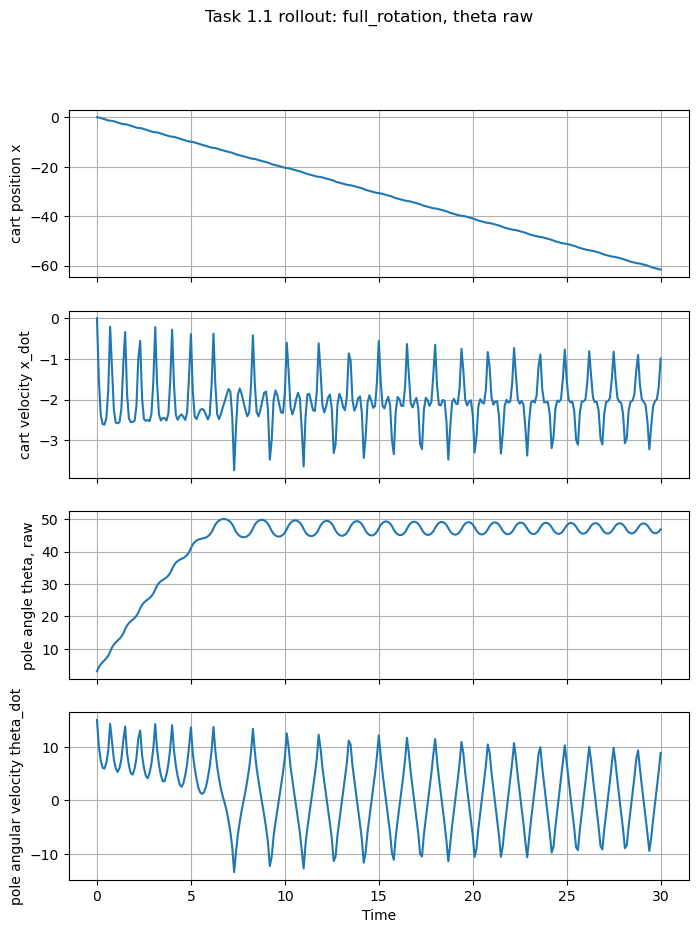

In [9]:
plot_time_series(
    rollouts["full_rotation"],
    "full_rotation",
    remap_theta=False
)

In [10]:
def plot_phase_portraits(trajectory, name, remap_theta=True):
    """
    Plot phase portraits:
        x vs x_dot
        theta vs theta_dot
    """
    if remap_theta:
        trajectory_to_plot = trajectory_with_remapped_angle(trajectory)
        theta_label = "theta, remapped"
        suffix = "remapped"
    else:
        trajectory_to_plot = trajectory
        theta_label = "theta, raw"
        suffix = "raw"

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(trajectory_to_plot[:, 0], trajectory_to_plot[:, 1])
    axes[0].set_xlabel("cart position x")
    axes[0].set_ylabel("cart velocity x_dot")
    axes[0].set_title("Cart phase portrait")
    axes[0].grid(True)

    axes[1].plot(trajectory_to_plot[:, 2], trajectory_to_plot[:, 3])
    axes[1].set_xlabel(theta_label)
    axes[1].set_ylabel("theta_dot")
    axes[1].set_title("Pole phase portrait")
    axes[1].grid(True)

    fig.suptitle(f"Task 1.1 phase portraits: {name}")

    filename = f"sf3_task1_1_phase_portraits_{name}_{suffix}.png"
    save_figure(fig, filename)

    plt.show()

In [11]:
for name, trajectory in rollouts.items():
    theta_raw = trajectory[:, 2]
    theta_remapped = remap_angle_array(theta_raw)

    num_cycles_raw = (theta_raw.max() - theta_raw.min()) / (2 * np.pi)

    print(name)
    print("  x range:", trajectory[:, 0].min(), "to", trajectory[:, 0].max())
    print("  x_dot range:", trajectory[:, 1].min(), "to", trajectory[:, 1].max())
    print("  raw theta range:", theta_raw.min(), "to", theta_raw.max())
    print("  remapped theta range:", theta_remapped.min(), "to", theta_remapped.max())
    print("  theta_dot range:", trajectory[:, 3].min(), "to", trajectory[:, 3].max())
    print("  approximate raw theta range in cycles:", num_cycles_raw)
    print()

small_oscillation
  x range: -7.37736572956312 to 0.0
  x_dot range: -0.4928615305472548 to 0.0
  raw theta range: 2.8530078667286176 to 3.4260643740381025
  remapped theta range: -3.141267349976175 to 3.141592653589793
  theta_dot range: -1.945676866771358 to 2.0
  approximate raw theta range in cycles: 0.09120477580928137

large_oscillation
  x range: -29.483273848693212 to 0.0
  x_dot range: -1.9591302057516349 to 0.0
  raw theta range: 1.9363435740659203 to 4.377220499018058
  remapped theta range: -3.1414246365288885 to 3.141592653589793
  theta_dot range: -7.773623881684236 to 8.0
  approximate raw theta range in cycles: 0.3884776280850781

full_rotation
  x range: -61.589816734039104 to 0.0
  x_dot range: -3.7395783679266956 to 0.0
  raw theta range: 3.141592653589793 to 49.98908101894895
  remapped theta range: -3.1224595462237517 to 3.141592653589793
  theta_dot range: -13.37421795518018 to 15.0
  approximate raw theta range in cycles: 7.456009344786965

